# Downstream

In [1]:
import pandas as pd

file_path = "Data2026.xlsx"
df = pd.read_excel(file_path)

print(df.head(10))

    Name       Type       City  Latitude  Longitude   Country
0     F1   Supplier     Poznan  52.40638  16.925170   Pologne
1     F2   Supplier  Marseille  43.29648   5.369780    France
2  PTF 1  Plateform       Lyon  45.76404   4.835659    France
3  PTF 2  Plateform    Amiens2  49.86936   2.209222    France
4  PTF 3  Plateform  Bruxelles  50.85000   4.350000  Belgique
5  PTF 4  Plateform  Barcelone  41.38506   2.173404   Espagne
6     C1  Customers      Lille  50.62925   3.057256    France
7     C2  Customers     Rennes  48.11348  -1.675708    France
8     C3  Customers     Amiens  49.89407   2.295753    France
9     C4  Customers      Dijon  47.32205   5.041480    France


In [2]:
import pandas as pd
import pulp

# -----------------------------
# 1) Load data from Excel
# -----------------------------
file_path = "Data2026.xlsx"

platform_df = pd.read_excel(file_path, sheet_name="Plateform")
demand_df = pd.read_excel(file_path, sheet_name="Customers Demand")
cost_df_raw = pd.read_excel(file_path, sheet_name="Transport cost")

# Standardize text fields (avoid mismatch caused by spaces/case)
for col in ["Plateform"]:
    if col in platform_df.columns:
        platform_df[col] = platform_df[col].astype(str).str.strip()

for col in ["Customer", "Product"]:
    if col in demand_df.columns:
        demand_df[col] = demand_df[col].astype(str).str.strip()

for col in ["SiteType#Name", "GeoPoint#Name", "SiteType_1#Name", "GeoPoint_1#Name"]:
    if col in cost_df_raw.columns:
        cost_df_raw[col] = cost_df_raw[col].astype(str).str.strip()

# -----------------------------
# 2) Build model inputs
# -----------------------------
# Demand by customer-product
req_demand_cols = {"Customer", "Product", "Demande"}
missing_demand = req_demand_cols - set(demand_df.columns)
if missing_demand:
    raise ValueError(f"Missing columns in Customers Demand sheet: {missing_demand}")

demand = (
    demand_df.groupby(["Customer", "Product"], as_index=False)["Demande"]
    .sum()
)

# Platform capacity (total end-product capacity)
req_platform_cols = {"Plateform", "Max capacity"}
missing_platform = req_platform_cols - set(platform_df.columns)
if missing_platform:
    raise ValueError(f"Missing columns in Plateform sheet: {missing_platform}")

capacity = (
    platform_df[["Plateform", "Max capacity"]]
    .dropna()
    .drop_duplicates(subset=["Plateform"])
)

# Transport cost from platform to customer
req_cost_cols = {"SiteType#Name", "GeoPoint#Name", "SiteType_1#Name", "GeoPoint_1#Name", "€/U"}
missing_cost = req_cost_cols - set(cost_df_raw.columns)
if missing_cost:
    raise ValueError(f"Missing columns in Transport cost sheet: {missing_cost}")

cost_df = cost_df_raw[
    (cost_df_raw["SiteType#Name"] == "Plateform") &
    (cost_df_raw["SiteType_1#Name"] == "Customers")
].copy()

cost_df = cost_df[["GeoPoint#Name", "GeoPoint_1#Name", "€/U"]].rename(
    columns={
        "GeoPoint#Name": "Supplier",
        "GeoPoint_1#Name": "Customer",
        "€/U": "UnitCost"
    }
)

# Sets
suppliers = sorted(capacity["Plateform"].unique().tolist())
customers = sorted(demand["Customer"].unique().tolist())
products = sorted(demand["Product"].unique().tolist())

# Dictionaries for fast lookup
cap = dict(zip(capacity["Plateform"], capacity["Max capacity"]))
production_cost = dict(zip(platform_df["Plateform"], platform_df["Production cost (€/u)"]))
unit_cost = {(r.Supplier, r.Customer): r.UnitCost for r in cost_df.itertuples(index=False)}

# Keep only lanes with known transport cost
valid_lanes = set(unit_cost.keys())

# -----------------------------
# 3) Build optimization model (PuLP)
# -----------------------------
model = pulp.LpProblem("Supplier_to_Customer_Shipping", pulp.LpMinimize)

x = {}
for s in suppliers:
    for c in customers:
        if (s, c) in valid_lanes:
            for p in products:
                x[(s, c, p)] = pulp.LpVariable(f"x_{s}_{c}_{p}", lowBound=0, cat="Continuous")

# Objective: minimize transport cost plus production cost
model += pulp.lpSum((unit_cost[(s, c)] + production_cost[s]) * x[(s, c, p)] for (s, c, p) in x), "Total_Transport_And_Production_Cost"

# Demand constraints: each customer-product demand must be satisfied exactly
for row in demand.itertuples(index=False):
    c = row.Customer
    p = row.Product
    q = float(row.Demande)

    vars_cp = [x[(s, c, p)] for s in suppliers if (s, c, p) in x]
    if not vars_cp:
        raise ValueError(f"No feasible shipping lane to satisfy demand for customer={c}, product={p}")

    model += pulp.lpSum(vars_cp) == q, f"Demand_{c}_{p}"

# Capacity constraints: total shipped from each supplier <= max capacity
for s in suppliers:
    vars_s = [x[(s, c, p)] for c in customers for p in products if (s, c, p) in x]
    model += pulp.lpSum(vars_s) <= float(cap[s]), f"Capacity_{s}"

# Solve
status = model.solve(pulp.PULP_CBC_CMD(msg=False))
print("Solver status:", pulp.LpStatus[status])
print("Optimal total cost:", round(pulp.value(model.objective), 2))

# -----------------------------
# 4) Build answer tables
# -----------------------------
solution_rows = []
for (s, c, p), var in x.items():
    q = var.value()
    if q is not None and q > 1e-6:
        solution_rows.append(
            {
                "Supplier": s,
                "Customer": c,
                "Product": p,
                "Quantity": float(q),
                "UnitCost": float(unit_cost[(s, c)] + production_cost[s]),
                "TotalCost": float(q) * float(unit_cost[(s, c)] + production_cost[s])
            }
        )

solution_df = pd.DataFrame(solution_rows).sort_values(["Supplier", "Customer", "Product"])

print("\nDetailed shipment plan (Supplier -> Customer by Product):")
display(solution_df)

lane_totals = (
    solution_df.groupby(["Supplier", "Customer"], as_index=False)[["Quantity", "TotalCost"]]
    .sum()
    .sort_values(["Supplier", "Customer"])
)

print("\nTotal quantity and cost on each Supplier -> Customer lane:")
display(lane_totals)


Solver status: Optimal
Optimal total cost: 626793.5

Detailed shipment plan (Supplier -> Customer by Product):


,Supplier,Customer,Product,Quantity,UnitCost,TotalCost
0,PTF 1,C10,P1,110.0,50.00,5500.00
1,PTF 1,C10,P2,234.0,50.00,11700.00
2,PTF 1,C4,P1,133.0,91.00,12103.00
3,PTF 1,C4,P2,126.0,91.00,11466.00
4,PTF 1,C4,P3,140.0,91.00,12740.00
5,PTF 1,C5,P1,122.0,51.00,6222.00
6,PTF 1,C5,P2,144.0,51.00,7344.00
7,PTF 2,C15,P1,340.0,115.50,39270.00
8,PTF 2,C15,P2,49.0,115.50,5659.50
9,PTF 2,C15,P3,133.0,115.50,15361.50



Total quantity and cost on each Supplier -> Customer lane:


,Supplier,Customer,Quantity,TotalCost
0,PTF 1,C10,344.0,17200.0
1,PTF 1,C4,399.0,36309.0
2,PTF 1,C5,266.0,13566.0
3,PTF 2,C15,722.0,83391.0
4,PTF 2,C2,426.0,75402.0
5,PTF 2,C3,650.0,5525.0
6,PTF 2,C6,560.0,85960.0
7,PTF 3,C1,277.0,12548.1
8,PTF 3,C7,445.0,11347.5
9,PTF 3,C8,386.0,8279.7


In [3]:
print(pulp.value(model.objective))

626793.5


# Upstream

In [4]:
import pandas as pd
import pulp

# -----------------------------
# 1) Load upstream-specific sheets
# -----------------------------
file_path = "Data2026.xlsx"
process_df = pd.read_excel(file_path, sheet_name="Process")
supplier_df = pd.read_excel(file_path, sheet_name="Suppliers")
cost_df_raw = pd.read_excel(file_path, sheet_name="Transport cost")

# Standardize column names and text values
for df in [process_df, supplier_df, cost_df_raw]:
    df.columns = df.columns.str.strip()
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].astype(str).str.strip()

# -----------------------------
# 2) Build BOM in long format from Process sheet
# -----------------------------
platform_col = "Plateforme" if "Plateforme" in process_df.columns else "Plateform"
if platform_col not in process_df.columns or "Product" not in process_df.columns:
    raise ValueError("Process sheet must contain platform and Product columns")

raw_cols = [c for c in process_df.columns if c.lower().startswith("raw")]
if not raw_cols:
    raise ValueError("No raw material columns found in Process sheet")

bom_long = process_df.melt(
    id_vars=[platform_col, "Product"],
    value_vars=raw_cols,
    var_name="RawCol",
    value_name="BOMQty"
).dropna(subset=["BOMQty"])

# Convert column names like 'Raw material A' -> material code 'A'
bom_long["Material"] = bom_long["RawCol"].str.extract(r"([A-Za-z0-9]+)$")[0].str.upper()
bom_long = bom_long.rename(columns={platform_col: "Platform"})

# -----------------------------
# 3) Compute platform raw-material demand D_m,i
# -----------------------------
# solution_df from downstream: Supplier = platform, Quantity by product
platform_product_qty = (
    solution_df.groupby(["Supplier", "Product"], as_index=False)["Quantity"].sum()
    .rename(columns={"Supplier": "Platform"})
)

demand_long = platform_product_qty.merge(
    bom_long[["Platform", "Product", "Material", "BOMQty"]],
    on=["Platform", "Product"],
    how="left"
).dropna(subset=["BOMQty"])

demand_long["RawDemand"] = demand_long["Quantity"] * demand_long["BOMQty"]
D = demand_long.groupby(["Platform", "Material"], as_index=False)["RawDemand"].sum()
D_dict = {(r.Platform, r.Material): float(r.RawDemand) for r in D.itertuples(index=False)}

# -----------------------------
# 4) Build upstream cost and supplier dictionaries
# -----------------------------
cost_up = cost_df_raw[
    (cost_df_raw["SiteType#Name"] == "Supplier") &
    (cost_df_raw["SiteType_1#Name"] == "Plateform")
] .copy()

cost_up = cost_up[["GeoPoint#Name", "GeoPoint_1#Name", "€/U"]].rename(
    columns={"GeoPoint#Name": "Supplier", "GeoPoint_1#Name": "Platform", "€/U": "TransportCost"}
)
T = {(r.Supplier, r.Platform): float(r.TransportCost) for r in cost_up.itertuples(index=False)}

# Keep only raw material rows from supplier sheet
supplier_raw = supplier_df.copy()
if "Product type" in supplier_raw.columns:
    supplier_raw = supplier_raw[supplier_raw["Product type"].str.lower() == "raw material"].copy()

supplier_raw["Material"] = supplier_raw["Product"].astype(str).str.upper()

required_supplier_cols = {"Supplier", "Material", "Purchasing cost (€/u)", "Max capacity"}
missing_supplier_cols = required_supplier_cols - set(supplier_raw.columns)
if missing_supplier_cols:
    raise ValueError(f"Missing columns in Suppliers sheet: {missing_supplier_cols}")

P_cost = {(r.Supplier, r.Material): float(r[2]) for r in supplier_raw[["Supplier", "Material", "Purchasing cost (€/u)"]].itertuples(index=False)}
C_cap  = {(r.Supplier, r.Material): float(r[2]) for r in supplier_raw[["Supplier", "Material", "Max capacity"]].itertuples(index=False)}

suppliers_up = sorted(supplier_raw["Supplier"].unique())
platforms_up = sorted(platform_product_qty["Platform"].unique())
materials = sorted(supplier_raw["Material"].unique())
valid_lanes_up = set(T.keys())

# -----------------------------
# 5) Build optimization model
# -----------------------------
model_up = pulp.LpProblem("Upstream_Supplier_to_Platform", pulp.LpMinimize)

y = {}
for m in materials:
    for s in suppliers_up:
        for i in platforms_up:
            if (s, i) in valid_lanes_up and (s, m) in P_cost:
                y[(m, s, i)] = pulp.LpVariable(f"y_{m}_{s}_{i}", lowBound=0, cat="Continuous")

model_up += pulp.lpSum(
    (T[(s, i)] + P_cost[(s, m)]) * y[(m, s, i)]
    for (m, s, i) in y
), "Total_Upstream_Cost"

# Meet each platform-material demand
for m in materials:
    for i in platforms_up:
        demand_mi = D_dict.get((i, m), 0.0)
        vars_mi = [y[(m, s, i)] for s in suppliers_up if (m, s, i) in y]
        if vars_mi:
            model_up += pulp.lpSum(vars_mi) >= demand_mi, f"Demand_{m}_{i}"

# Respect each supplier-material capacity
for m in materials:
    for s in suppliers_up:
        cap_ms = C_cap.get((s, m), 0.0)
        vars_ms = [y[(m, s, i)] for i in platforms_up if (m, s, i) in y]
        if vars_ms:
            model_up += pulp.lpSum(vars_ms) <= cap_ms, f"Capacity_{s}_{m}"

# -----------------------------
# 6) Solve & display
# -----------------------------
status_up = model_up.solve(pulp.PULP_CBC_CMD(msg=False))
print("Upstream solver status:", pulp.LpStatus[status_up])
print("Optimal upstream cost:", round(pulp.value(model_up.objective), 2))

upstream_rows = []
for (m, s, i), var in y.items():
    q = var.value()
    if q is not None and q > 1e-6:
        unit_cost = T[(s, i)] + P_cost[(s, m)]
        upstream_rows.append({
            "Material": m,
            "Supplier": s,
            "Platform": i,
            "Quantity": round(float(q), 2),
            "UnitCost": round(float(unit_cost), 2),
            "TotalCost": round(float(q) * float(unit_cost), 2)
        })

upstream_df = pd.DataFrame(upstream_rows)
if not upstream_df.empty:
    upstream_df = upstream_df.sort_values(["Supplier", "Platform", "Material"])
display(upstream_df)

Upstream solver status: Optimal
Optimal upstream cost: 701237.14


,Material,Supplier,Platform,Quantity,UnitCost,TotalCost
0,A,F1,PTF 2,816.50,144.19,117731.13
4,B,F1,PTF 2,1251.38,145.19,181687.86
1,A,F1,PTF 3,322.91,120.92,39046.28
5,B,F1,PTF 3,548.62,121.92,66887.75
2,A,F2,PTF 1,353.30,107.30,37909.09
6,B,F2,PTF 1,412.40,109.30,45075.32
7,B,F2,PTF 2,29.62,281.50,8338.03
3,A,F2,PTF 4,499.80,128.30,64124.34
8,B,F2,PTF 4,1077.80,130.30,140437.34


# Global problem

In [5]:
# =============================================================
# GLOBAL MODEL — joint optimization of x (downstream) and y (upstream)
# =============================================================
import pandas as pd
import pulp

file_path = "Data2026.xlsx"

# ---- Load all sheets ----
platform_df  = pd.read_excel(file_path, sheet_name="Plateform")
demand_df    = pd.read_excel(file_path, sheet_name="Customers Demand")
cost_df_raw  = pd.read_excel(file_path, sheet_name="Transport cost")
process_df   = pd.read_excel(file_path, sheet_name="Process")
supplier_df  = pd.read_excel(file_path, sheet_name="Suppliers")

for df in [platform_df, demand_df, cost_df_raw, process_df, supplier_df]:
    df.columns = df.columns.str.strip()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str).str.strip()

# ---- Dictionaries ----
demand = demand_df.groupby(["Customer", "Product"], as_index=False)["Demande"].sum()
D_down = {(r.Customer, r.Product): float(r.Demande) for r in demand.itertuples(index=False)}

C_ptf  = dict(zip(platform_df["Plateform"], platform_df["Max capacity"].astype(float)))
P_prod = dict(zip(platform_df["Plateform"], platform_df["Production cost (€/u)"].astype(float)))

cost_down = cost_df_raw[
    (cost_df_raw["SiteType#Name"] == "Plateform") &
    (cost_df_raw["SiteType_1#Name"] == "Customers")
][["GeoPoint#Name", "GeoPoint_1#Name", "€/U"]].rename(
    columns={"GeoPoint#Name": "Platform", "GeoPoint_1#Name": "Customer", "€/U": "T_down"}
)
T_down = {(r.Platform, r.Customer): float(r.T_down) for r in cost_down.itertuples(index=False)}

cost_up = cost_df_raw[
    (cost_df_raw["SiteType#Name"] == "Supplier") &
    (cost_df_raw["SiteType_1#Name"] == "Plateform")
][["GeoPoint#Name", "GeoPoint_1#Name", "€/U"]].rename(
    columns={"GeoPoint#Name": "Supplier", "GeoPoint_1#Name": "Platform", "€/U": "T_up"}
)
T_up = {(r.Supplier, r.Platform): float(r.T_up) for r in cost_up.itertuples(index=False)}

# Rename special-char column so itertuples works cleanly
supplier_df = supplier_df.rename(columns={
    "Purchasing cost (€/u)": "PurchCost",
    "Max capacity": "MaxCap",
})
P_purch = {(r.Supplier, r.Product): float(r.PurchCost) for r in supplier_df.itertuples(index=False)}
C_sup   = {(r.Supplier, r.Product): float(r.MaxCap)    for r in supplier_df.itertuples(index=False)}

# BOM:  q_bom[(product, material, platform)]  — column "Raw metrial B" typo kept
bom_long = process_df.melt(
    id_vars=["Plateforme", "Product"],
    value_vars=["Raw material A", "Raw metrial B"],
    var_name="RawCol", value_name="BOMQty"
).dropna(subset=["BOMQty"])
bom_long["Material"] = bom_long["RawCol"].str[-1].str.upper()
q_bom = {
    (r.Product, r.Material, r.Plateforme): float(r.BOMQty)
    for r in bom_long.itertuples(index=False)
}

platforms = sorted(platform_df["Plateform"].unique())
customers = sorted(demand["Customer"].unique())
products  = sorted(demand["Product"].unique())
suppliers = sorted(supplier_df["Supplier"].unique())
materials = ["A", "B"]

# ---- Model ----
m_g = pulp.LpProblem("Global_Network", pulp.LpMinimize)

x = {(p, i, j): pulp.LpVariable(f"x_{p}_{i}_{j}", lowBound=0)
     for p in products for i in platforms for j in customers if (i, j) in T_down}

y = {(mat, s, i): pulp.LpVariable(f"y_{mat}_{s}_{i}", lowBound=0)
     for mat in materials for s in suppliers for i in platforms
     if (s, i) in T_up and (s, mat) in P_purch}

# Objective: transport + production downstream + transport + purchasing upstream
m_g += (
    pulp.lpSum((T_down[(i, j)] + P_prod[i]) * x[(p, i, j)] for (p, i, j) in x)
    + pulp.lpSum((T_up[(s, i)] + P_purch[(s, mat)]) * y[(mat, s, i)] for (mat, s, i) in y)
), "Total_Cost"

# (1) meet customer demand
for (j, p), d in D_down.items():
    vars_jp = [x[(p, i, j)] for i in platforms if (p, i, j) in x]
    if vars_jp:
        m_g += pulp.lpSum(vars_jp) >= d, f"Demand_{p}_{j}"

# (2) platform capacity (total end-product flow)
for i in platforms:
    vars_i = [x[(p, i, j)] for p in products for j in customers if (p, i, j) in x]
    if vars_i:
        m_g += pulp.lpSum(vars_i) <= C_ptf[i], f"PlatformCap_{i}"

# (3) raw material balance: inflow >= consumption (BOM-driven)
for mat in materials:
    for i in platforms:
        in_side = [y[(mat, s, i)] for s in suppliers if (mat, s, i) in y]
        cons    = [x[(p, i, j)] * q_bom.get((p, mat, i), 0.0)
                   for p in products for j in customers if (p, i, j) in x]
        if in_side and cons:
            m_g += pulp.lpSum(in_side) >= pulp.lpSum(cons), f"RawMat_{mat}_{i}"

# (4) supplier capacity per material
for s in suppliers:
    for mat in materials:
        vars_sm = [y[(mat, s, i)] for i in platforms if (mat, s, i) in y]
        if vars_sm:
            m_g += pulp.lpSum(vars_sm) <= C_sup.get((s, mat), 0.0), f"SupCap_{s}_{mat}"

status_g = m_g.solve(pulp.PULP_CBC_CMD(msg=False))
global_cost = pulp.value(m_g.objective)

global_down_cost = sum(
    (T_down[(i, j)] + P_prod[i]) * x[(p, i, j)].value()
    for (p, i, j) in x if x[(p, i, j)].value() and x[(p, i, j)].value() > 1e-6
)
global_up_cost = sum(
    (T_up[(s, i)] + P_purch[(s, mat)]) * y[(mat, s, i)].value()
    for (mat, s, i) in y if y[(mat, s, i)].value() and y[(mat, s, i)].value() > 1e-6
)

print("Global solver status:", pulp.LpStatus[status_g])
print("Global total cost:    {:,.2f} €".format(global_cost))
print("  downstream part:    {:,.2f} €".format(global_down_cost))
print("  upstream   part:    {:,.2f} €".format(global_up_cost))

# ---- Result tables ----
down_rows = []
for (p, i, j), var in x.items():
    q = var.value()
    if q and q > 1e-6:
        down_rows.append({
            "Platform": i, "Customer": j, "Product": p,
            "Quantity": round(q, 2),
            "UnitCost": round(T_down[(i, j)] + P_prod[i], 2),
            "TotalCost": round(q * (T_down[(i, j)] + P_prod[i]), 2),
        })
down_global_df = pd.DataFrame(down_rows).sort_values(["Platform", "Customer", "Product"])

up_rows = []
for (mat, s, i), var in y.items():
    q = var.value()
    if q and q > 1e-6:
        up_rows.append({
            "Supplier": s, "Platform": i, "Material": mat,
            "Quantity": round(q, 2),
            "UnitCost": round(T_up[(s, i)] + P_purch[(s, mat)], 2),
            "TotalCost": round(q * (T_up[(s, i)] + P_purch[(s, mat)]), 2),
        })
up_global_df = pd.DataFrame(up_rows).sort_values(["Supplier", "Platform", "Material"])

print("\n--- Global downstream flows (Platform → Customer) ---")
display(down_global_df)
print("\n--- Global upstream flows (Supplier → Platform) ---")
display(up_global_df)


Global solver status: Optimal
Global total cost:    1,260,728.94 €
  downstream part:    683,246.50 €
  upstream   part:    577,482.44 €

--- Global downstream flows (Platform → Customer) ---


,Platform,Customer,Product,Quantity,UnitCost,TotalCost
0,PTF 1,C10,P1,110.0,50.00,5500.00
13,PTF 1,C10,P2,234.0,50.00,11700.00
14,PTF 1,C15,P2,49.0,147.50,7227.50
37,PTF 1,C15,P4,200.0,147.50,29500.00
1,PTF 1,C4,P1,133.0,91.00,12103.00
15,PTF 1,C4,P2,126.0,91.00,11466.00
28,PTF 1,C4,P3,140.0,91.00,12740.00
2,PTF 1,C5,P1,122.0,51.00,6222.00
16,PTF 1,C5,P2,144.0,51.00,7344.00
17,PTF 1,C6,P2,242.0,186.50,45133.00



--- Global upstream flows (Supplier → Platform) ---


,Supplier,Platform,Material,Quantity,UnitCost,TotalCost
0,F1,PTF 2,A,351.20,144.19,50639.53
4,F1,PTF 2,B,340.40,145.19,49422.68
1,F1,PTF 3,A,599.73,120.92,72519.35
5,F1,PTF 3,B,855.16,121.92,104261.11
2,F2,PTF 1,A,435.50,107.30,46729.15
6,F2,PTF 1,B,451.50,109.30,49348.95
3,F2,PTF 4,A,499.80,128.30,64124.34
7,F2,PTF 4,B,1077.80,130.30,140437.34


# Baseline scenario

Force all flows onto the lanes listed in the **Base line** sheet (current real network) and re-solve. The cost we get becomes the reference for every optimization scenario.

In [6]:
# =============================================================
# BASELINE — recreate the current real network
# All lanes NOT listed in the "Base line" sheet are forced to 0.
# Reuses the dictionaries built in the Global cell above.
# =============================================================
import pandas as pd
import pulp

file_path = "Data2026.xlsx"
baseline_df = pd.read_excel(file_path, sheet_name="Base line")
baseline_df.columns = baseline_df.columns.str.strip()
for col in baseline_df.columns:
    if baseline_df[col].dtype == "object":
        baseline_df[col] = baseline_df[col].astype(str).str.strip()

# Active lanes from the baseline sheet
baseline_down_lanes = set(
    baseline_df[baseline_df["SiteType#Name"] == "Plateform"]
    [["GeoPoint#Name", "GeoPoint_1#Name"]].apply(tuple, axis=1)
)
baseline_up_lanes = set(
    baseline_df[baseline_df["SiteType#Name"] == "Supplier"]
    [["GeoPoint#Name", "GeoPoint_1#Name"]].apply(tuple, axis=1)
)
print(f"Active downstream lanes in baseline: {len(baseline_down_lanes)}")
print(f"Active upstream   lanes in baseline: {len(baseline_up_lanes)}")

# ---- Baseline model (same structure as global, plus lane fixings) ----
m_b = pulp.LpProblem("Baseline", pulp.LpMinimize)

xb = {(p, i, j): pulp.LpVariable(f"xb_{p}_{i}_{j}", lowBound=0)
      for p in products for i in platforms for j in customers if (i, j) in T_down}

yb = {(mat, s, i): pulp.LpVariable(f"yb_{mat}_{s}_{i}", lowBound=0)
      for mat in materials for s in suppliers for i in platforms
      if (s, i) in T_up and (s, mat) in P_purch}

m_b += (
    pulp.lpSum((T_down[(i, j)] + P_prod[i]) * xb[(p, i, j)] for (p, i, j) in xb)
    + pulp.lpSum((T_up[(s, i)] + P_purch[(s, mat)]) * yb[(mat, s, i)] for (mat, s, i) in yb)
), "Baseline_Total_Cost"

# Demand
for (j, p), d in D_down.items():
    vars_jp = [xb[(p, i, j)] for i in platforms if (p, i, j) in xb]
    if vars_jp:
        m_b += pulp.lpSum(vars_jp) >= d, f"DemandB_{p}_{j}"

# Force non-baseline lanes to 0
for (p, i, j), var in xb.items():
    if (i, j) not in baseline_down_lanes:
        m_b += var == 0, f"OffDown_{p}_{i}_{j}"
for (mat, s, i), var in yb.items():
    if (s, i) not in baseline_up_lanes:
        m_b += var == 0, f"OffUp_{mat}_{s}_{i}"

# Platform capacity
for i in platforms:
    vars_i = [xb[(p, i, j)] for p in products for j in customers if (p, i, j) in xb]
    if vars_i:
        m_b += pulp.lpSum(vars_i) <= C_ptf[i], f"PlatCapB_{i}"

# Raw material balance
for mat in materials:
    for i in platforms:
        in_side = [yb[(mat, s, i)] for s in suppliers if (mat, s, i) in yb]
        cons    = [xb[(p, i, j)] * q_bom.get((p, mat, i), 0.0)
                   for p in products for j in customers if (p, i, j) in xb]
        if in_side and cons:
            m_b += pulp.lpSum(in_side) >= pulp.lpSum(cons), f"RawMatB_{mat}_{i}"

# Supplier capacity
for s in suppliers:
    for mat in materials:
        vars_sm = [yb[(mat, s, i)] for i in platforms if (mat, s, i) in yb]
        if vars_sm:
            m_b += pulp.lpSum(vars_sm) <= C_sup.get((s, mat), 0.0), f"SupCapB_{s}_{mat}"

status_b = m_b.solve(pulp.PULP_CBC_CMD(msg=False))
baseline_cost = pulp.value(m_b.objective)

print("Baseline solver status:", pulp.LpStatus[status_b])
print("Baseline total cost:   {:,.2f} €".format(baseline_cost))
print("Optimized global cost: {:,.2f} €".format(global_cost))
print("Savings (optimized vs baseline): {:,.2f} €  ({:.2f}%)".format(
    baseline_cost - global_cost,
    100 * (baseline_cost - global_cost) / baseline_cost,
))

# Baseline flow tables
bl_rows = []
for (p, i, j), var in xb.items():
    q = var.value()
    if q and q > 1e-6:
        bl_rows.append({
            "Platform": i, "Customer": j, "Product": p,
            "Quantity": round(q, 2),
            "TotalCost": round(q * (T_down[(i, j)] + P_prod[i]), 2),
        })
baseline_down_df = pd.DataFrame(bl_rows).sort_values(["Platform", "Customer", "Product"])

bl_up_rows = []
for (mat, s, i), var in yb.items():
    q = var.value()
    if q and q > 1e-6:
        bl_up_rows.append({
            "Supplier": s, "Platform": i, "Material": mat,
            "Quantity": round(q, 2),
            "TotalCost": round(q * (T_up[(s, i)] + P_purch[(s, mat)]), 2),
        })
baseline_up_df = pd.DataFrame(bl_up_rows).sort_values(["Supplier", "Platform", "Material"])

print("\n--- Baseline downstream flows (Platform → Customer) ---")
display(baseline_down_df)
print("\n--- Baseline upstream flows (Supplier → Platform) ---")
display(baseline_up_df)


Active downstream lanes in baseline: 15
Active upstream   lanes in baseline: 4


Baseline solver status: Optimal
Baseline total cost:   1,811,047.18 €
Optimized global cost: 1,260,728.94 €
Savings (optimized vs baseline): 550,318.24 €  (30.39%)

--- Baseline downstream flows (Platform → Customer) ---


,Platform,Customer,Product,Quantity,TotalCost
0,PTF 1,C10,P1,110.0,5500.00
13,PTF 1,C10,P2,234.0,11700.00
1,PTF 1,C11,P1,300.0,55200.00
27,PTF 1,C11,P3,102.0,18768.00
14,PTF 1,C12,P2,133.0,29526.00
15,PTF 1,C13,P2,140.0,26740.00
28,PTF 1,C13,P3,126.0,24066.00
2,PTF 1,C5,P1,122.0,6222.00
16,PTF 1,C5,P2,144.0,7344.00
3,PTF 2,C1,P1,133.0,7581.00



--- Baseline upstream flows (Supplier → Platform) ---


,Supplier,Platform,Material,Quantity,TotalCost
0,F1,PTF 3,A,247.56,29934.96
4,F1,PTF 3,B,423.42,51623.37
1,F2,PTF 1,A,510.20,54744.46
5,F2,PTF 1,B,604.70,66093.71
2,F2,PTF 2,A,1059.90,296242.05
6,F2,PTF 2,B,1630.40,458957.60
3,F2,PTF 4,A,252.30,32370.09
7,F2,PTF 4,B,564.50,73554.35


# Scenario 2 — Green Field (no capacity constraints)

## What is the Green Field scenario?

The **Green Field** scenario asks: *what is the absolute minimum cost if we had unlimited production capacity at every platform and unlimited supply from every supplier?*

It is called "Green Field" because we imagine building the network from a blank page — no physical limits, only transport and cost logic.

## What changes vs the Global model?

We **remove two families of constraints**:

| Constraint removed | Why |
|---|---|
| Platform capacity `Σ_j x_{p,i,j} ≤ C_i` | Platforms can handle any volume |
| Supplier capacity `Σ_i y_{m,s,i} ≤ C_{m,s}` | Suppliers can ship any quantity |

All other constraints remain:
- ✅ Customer demand must still be fully satisfied
- ✅ Raw material balance (BOM): platforms must receive enough raw material to produce what they ship

## Why is this useful?

The Green Field cost is the **theoretical lower bound** — the best we could ever achieve with this network topology.  
The gap between Green Field and the Global model (which respects capacities) tells us **how much the capacity constraints cost us**.

If the gap is large → investing in more capacity would have high ROI.  
If the gap is small → current capacities are not the bottleneck.

In [7]:
# =============================================================
# GREEN FIELD — remove platform and supplier capacity constraints
# Reuses all dictionaries built in the Global model cell above:
#   T_down, T_up, P_prod, P_purch, C_ptf, C_sup, q_bom,
#   D_down, platforms, customers, products, suppliers, materials
# =============================================================
import pulp

m_gf = pulp.LpProblem("GreenField", pulp.LpMinimize)

# Decision variables — same structure as the global model
# x_gf[p, i, j] = units of product p shipped from platform i to customer j
x_gf = {(p, i, j): pulp.LpVariable(f"xgf_{p}_{i}_{j}", lowBound=0)
         for p in products for i in platforms for j in customers if (i, j) in T_down}

# y_gf[mat, s, i] = units of raw material mat shipped from supplier s to platform i
y_gf = {(mat, s, i): pulp.LpVariable(f"ygf_{mat}_{s}_{i}", lowBound=0)
         for mat in materials for s in suppliers for i in platforms
         if (s, i) in T_up and (s, mat) in P_purch}

# Objective: minimize total cost (transport + production downstream, transport + purchasing upstream)
m_gf += (
    pulp.lpSum((T_down[(i, j)] + P_prod[i]) * x_gf[(p, i, j)] for (p, i, j) in x_gf)
    + pulp.lpSum((T_up[(s, i)] + P_purch[(s, mat)]) * y_gf[(mat, s, i)] for (mat, s, i) in y_gf)
), "GreenField_Total_Cost"

# --- Constraint 1: Meet customer demand (unchanged) ---
for (j, p), d in D_down.items():
    vars_jp = [x_gf[(p, i, j)] for i in platforms if (p, i, j) in x_gf]
    if vars_jp:
        m_gf += pulp.lpSum(vars_jp) >= d, f"Demand_GF_{p}_{j}"

# --- Constraint 2: Raw material balance (unchanged) ---
# Each platform must receive at least as much raw material as its production consumes.
# Consumption = Σ_p Σ_j  x_gf[p,i,j] * BOM_ratio[p, mat, i]
for mat in materials:
    for i in platforms:
        in_side = [y_gf[(mat, s, i)] for s in suppliers if (mat, s, i) in y_gf]
        cons    = [x_gf[(p, i, j)] * q_bom.get((p, mat, i), 0.0)
                   for p in products for j in customers if (p, i, j) in x_gf]
        if in_side and cons:
            m_gf += pulp.lpSum(in_side) >= pulp.lpSum(cons), f"RawMat_GF_{mat}_{i}"

# NOTE: Platform capacity and supplier capacity constraints are intentionally OMITTED.

# Solve
status_gf = m_gf.solve(pulp.PULP_CBC_CMD(msg=False))
gf_cost = pulp.value(m_gf.objective)

print("Green Field solver status:", pulp.LpStatus[status_gf])
print("Green Field total cost:    {:,.2f} €".format(gf_cost))
print()
print("--- Comparison ---")
print("Baseline cost (current real network):        {:,.2f} €".format(baseline_cost))
print("Global optimized cost (with capacities):     {:,.2f} €".format(global_cost))
print("Green Field cost (no capacity constraints):  {:,.2f} €".format(gf_cost))
print()
print("Gap Global → Green Field (cost of capacity): {:,.2f} € ({:.1f}%)".format(
    global_cost - gf_cost, 100 * (global_cost - gf_cost) / gf_cost))
print("Gap Baseline → Green Field (total savings potential): {:,.2f} € ({:.1f}%)".format(
    baseline_cost - gf_cost, 100 * (baseline_cost - gf_cost) / baseline_cost))

# Platform volumes — shows which platforms the optimizer favors when unconstrained
import pandas as pd
gf_rows = []
for (p, i, j), var in x_gf.items():
    q = var.value()
    if q and q > 1e-6:
        gf_rows.append({"Platform": i, "Customer": j, "Product": p, "Quantity": round(q, 2)})

gf_df = pd.DataFrame(gf_rows)
gf_vol = gf_df.groupby("Platform")["Quantity"].sum().reset_index()
gf_vol["Capacity"] = gf_vol["Platform"].map(C_ptf)
gf_vol["Would_exceed_cap"] = gf_vol["Quantity"] > gf_vol["Capacity"]
print()
print("Platform volumes in Green Field vs their capacity limits:")
display(gf_vol)

Green Field solver status: Optimal
Green Field total cost:    1,259,167.80 €

--- Comparison ---
Baseline cost (current real network):        1,811,047.18 €
Global optimized cost (with capacities):     1,260,728.94 €
Green Field cost (no capacity constraints):  1,259,167.80 €

Gap Global → Green Field (cost of capacity): 1,561.14 € (0.1%)
Gap Baseline → Green Field (total savings potential): 551,879.38 € (30.5%)

Platform volumes in Green Field vs their capacity limits:


,Platform,Quantity,Capacity,Would_exceed_cap
0,PTF 1,1731.0,1500.0,True
1,PTF 2,960.0,4000.0,False
2,PTF 3,1917.0,3000.0,False
3,PTF 4,1504.0,2500.0,False


# Scenario 3 — Backup: PTF 3 (Brussels) Closed

## What is the Backup scenario?

The **Backup scenario** (also called contingency or resilience scenario) asks:  
*What happens to our network and our costs if PTF 3 (Brussels) is forced to close?*

This could represent a real-world event such as:
- A regulatory shutdown (e.g. operating licence revoked in Belgium)
- A fire, flood, or major breakdown at the Brussels site
- A strategic decision to exit the Belgian market

## What changes vs the Global model?

We **add two families of constraints** that force all flows through PTF 3 to zero:

| Constraint added | Effect |
|---|---|
| `x[p, 'PTF 3', j] = 0` for all products p and customers j | PTF 3 ships nothing downstream |
| `y[mat, s, 'PTF 3'] = 0` for all materials and suppliers | PTF 3 receives no raw materials |

All other constraints remain identical to the Global model (capacities, BOM, demand).

## Why is this useful?

The extra cost vs the Global model measures the **strategic value of PTF 3** — how much closing it would cost the company.  
This is key information for a lease negotiation, an insurance claim, or a risk assessment.

In [8]:
# =============================================================
# BACKUP SCENARIO — PTF 3 (Brussels) is forced closed
# All flows in/out of PTF 3 are set to zero.
# The optimizer redistributes demand across PTF 1, PTF 2, PTF 4.
# Reuses all dictionaries built in the Global model cell above.
# =============================================================
import pulp
import pandas as pd

CLOSED_PLATFORM = "PTF 3"  # the platform we are shutting down

m_cl = pulp.LpProblem("PTF3_Closed", pulp.LpMinimize)

# Decision variables — same structure as the global model
x_cl = {(p, i, j): pulp.LpVariable(f"xcl_{p}_{i}_{j}", lowBound=0)
         for p in products for i in platforms for j in customers if (i, j) in T_down}

y_cl = {(mat, s, i): pulp.LpVariable(f"ycl_{mat}_{s}_{i}", lowBound=0)
         for mat in materials for s in suppliers for i in platforms
         if (s, i) in T_up and (s, mat) in P_purch}

# Objective: same total cost minimization
m_cl += (
    pulp.lpSum((T_down[(i, j)] + P_prod[i]) * x_cl[(p, i, j)] for (p, i, j) in x_cl)
    + pulp.lpSum((T_up[(s, i)] + P_purch[(s, mat)]) * y_cl[(mat, s, i)] for (mat, s, i) in y_cl)
), "Closure_Total_Cost"

# --- Constraint 1: Meet customer demand ---
for (j, p), d in D_down.items():
    vars_jp = [x_cl[(p, i, j)] for i in platforms if (p, i, j) in x_cl]
    if vars_jp:
        m_cl += pulp.lpSum(vars_jp) >= d, f"Demand_CL_{p}_{j}"

# --- Constraint 2: Force PTF 3 to zero (the closure) ---
# Every downstream variable leaving PTF 3 = 0
for (p, i, j), var in x_cl.items():
    if i == CLOSED_PLATFORM:
        m_cl += var == 0, f"Closed_down_{p}_{j}"

# Every upstream variable arriving at PTF 3 = 0
for (mat, s, i), var in y_cl.items():
    if i == CLOSED_PLATFORM:
        m_cl += var == 0, f"Closed_up_{mat}_{s}"

# --- Constraint 3: Remaining platform capacities (unchanged) ---
for i in platforms:
    vars_i = [x_cl[(p, i, j)] for p in products for j in customers if (p, i, j) in x_cl]
    if vars_i:
        m_cl += pulp.lpSum(vars_i) <= C_ptf[i], f"PlatCap_CL_{i}"

# --- Constraint 4: Raw material balance ---
for mat in materials:
    for i in platforms:
        in_side = [y_cl[(mat, s, i)] for s in suppliers if (mat, s, i) in y_cl]
        cons    = [x_cl[(p, i, j)] * q_bom.get((p, mat, i), 0.0)
                   for p in products for j in customers if (p, i, j) in x_cl]
        if in_side and cons:
            m_cl += pulp.lpSum(in_side) >= pulp.lpSum(cons), f"RawMat_CL_{mat}_{i}"

# --- Constraint 5: Supplier capacities (unchanged) ---
for s in suppliers:
    for mat in materials:
        vars_sm = [y_cl[(mat, s, i)] for i in platforms if (mat, s, i) in y_cl]
        if vars_sm:
            m_cl += pulp.lpSum(vars_sm) <= C_sup.get((s, mat), 0.0), f"SupCap_CL_{s}_{mat}"

# Solve
status_cl = m_cl.solve(pulp.PULP_CBC_CMD(msg=False))
closure_cost = pulp.value(m_cl.objective)

print("PTF 3 closure solver status:", pulp.LpStatus[status_cl])
print("PTF 3 closure total cost:    {:,.2f} €".format(closure_cost))
print()
print("--- Comparison ---")
print("Baseline cost:               {:,.2f} €".format(baseline_cost))
print("Global optimized (all open): {:,.2f} €".format(global_cost))
print("PTF 3 closed:                {:,.2f} €".format(closure_cost))
print()
print("Cost of closing PTF 3 (vs global): +{:,.2f} € (+{:.1f}%)".format(
    closure_cost - global_cost, 100 * (closure_cost - global_cost) / global_cost))
print("This is the strategic value of keeping PTF 3 open.")

# Show how the Belgian customers (C7=Ghent, C8=Antwerp) are now served
cl_rows = []
for (p, i, j), var in x_cl.items():
    q = var.value()
    if q and q > 1e-6:
        cl_rows.append({
            "Platform": i, "Customer": j, "Product": p,
            "Quantity": round(q, 2),
            "UnitCost": round(T_down[(i, j)] + P_prod[i], 2),
            "TotalCost": round(q * (T_down[(i, j)] + P_prod[i]), 2),
        })
cl_df = pd.DataFrame(cl_rows).sort_values(["Platform", "Customer", "Product"])

print()
print("--- Belgian customers (C7=Ghent, C8=Antwerp) — who serves them now? ---")
display(cl_df[cl_df["Customer"].isin(["C7", "C8"])])

print("--- Platform volumes after closure ---")
cl_vol = cl_df.groupby("Platform")["Quantity"].sum().reset_index()
cl_vol["Capacity"] = cl_vol["Platform"].map(C_ptf)
cl_vol["Utilisation_%"] = (cl_vol["Quantity"] / cl_vol["Capacity"] * 100).round(1)
display(cl_vol)

print("--- Full downstream flow plan after PTF 3 closure ---")
display(cl_df)

PTF 3 closure solver status: Optimal
PTF 3 closure total cost:    1,411,257.38 €

--- Comparison ---
Baseline cost:               1,811,047.18 €
Global optimized (all open): 1,260,728.94 €
PTF 3 closed:                1,411,257.38 €

Cost of closing PTF 3 (vs global): +150,528.44 € (+11.9%)
This is the strategic value of keeping PTF 3 open.

--- Belgian customers (C7=Ghent, C8=Antwerp) — who serves them now? ---


,Platform,Customer,Product,Quantity,UnitCost,TotalCost
9,PTF 2,C7,P1,200.0,90.0,18000.0
22,PTF 2,C7,P2,180.0,90.0,16200.0
32,PTF 2,C7,P3,65.0,90.0,5850.0
10,PTF 2,C8,P1,120.0,113.0,13560.0
23,PTF 2,C8,P2,83.0,113.0,9379.0
33,PTF 2,C8,P3,49.0,113.0,5537.0
39,PTF 2,C8,P4,134.0,113.0,15142.0


--- Platform volumes after closure ---


,Platform,Quantity,Capacity,Utilisation_%
0,PTF 1,1500.0,1500.0,100.0
1,PTF 2,2975.0,4000.0,74.4
2,PTF 4,1637.0,2500.0,65.5


--- Full downstream flow plan after PTF 3 closure ---


,Platform,Customer,Product,Quantity,UnitCost,TotalCost
0,PTF 1,C10,P1,110.0,50.00,5500.00
14,PTF 1,C10,P2,234.0,50.00,11700.00
1,PTF 1,C15,P1,291.0,147.50,42922.50
37,PTF 1,C15,P4,200.0,147.50,29500.00
2,PTF 1,C4,P1,133.0,91.00,12103.00
15,PTF 1,C4,P2,126.0,91.00,11466.00
28,PTF 1,C4,P3,140.0,91.00,12740.00
3,PTF 1,C5,P1,122.0,51.00,6222.00
16,PTF 1,C5,P2,144.0,51.00,7344.00
4,PTF 2,C1,P1,133.0,57.00,7581.00


# Scenario Comparison Summary

The table below is produced by the next cell.  
It compares all four scenarios on a single cost axis so you can explain the value of each lever during your presentation.

,Scenario,Description,Total Cost (€),vs Baseline (€),vs Baseline (%)
0,1. Baseline,Current real network (fixed historical lanes),1811047.18,0.00,0.0
1,2. Global Optimised,"All lanes open, all capacities respected",1260728.94,-550318.24,-30.4
2,3. Green Field,No platform or supplier capacity limits (theor...,1259167.80,-551879.38,-30.5
3,4. PTF 3 Closed (Backup),"Brussels platform shut down, demand redistributed",1411257.38,-399789.80,-22.1


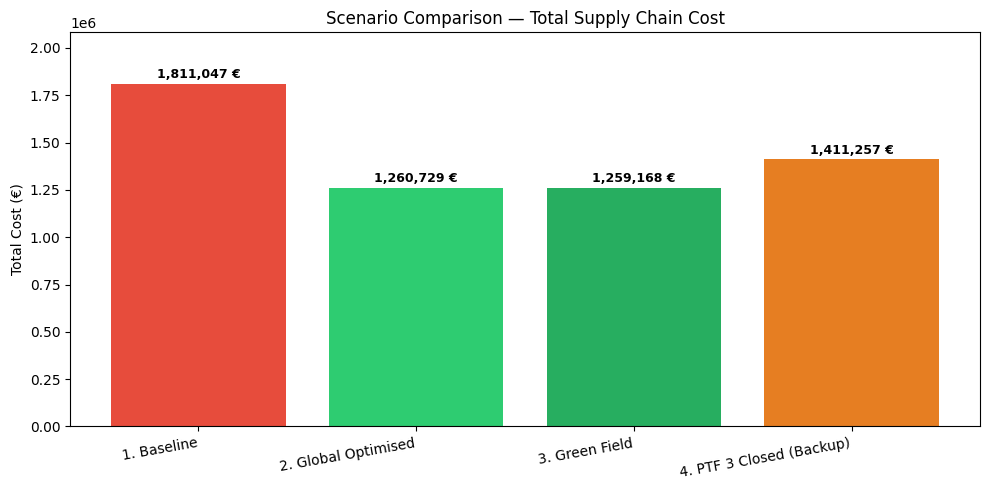


KEY INSIGHTS:
  • Optimising the routing alone (Baseline → Global) saves 550,318 € (30.4%)
  • Capacity constraints cost only 1,561 € — they are not the bottleneck
  • Closing PTF 3 (Brussels) costs an extra 150,528 € per year (+11.9%)
  • Even with PTF 3 closed, the optimised network is still 399,790 € cheaper than the baseline


In [9]:
# =============================================================
# SCENARIO COMPARISON TABLE
# Summarises the four scenarios in a single table and bar chart.
# =============================================================
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    {
        "Scenario": "1. Baseline",
        "Description": "Current real network (fixed historical lanes)",
        "Total Cost (€)": baseline_cost,
    },
    {
        "Scenario": "2. Global Optimised",
        "Description": "All lanes open, all capacities respected",
        "Total Cost (€)": global_cost,
    },
    {
        "Scenario": "3. Green Field",
        "Description": "No platform or supplier capacity limits (theoretical minimum)",
        "Total Cost (€)": gf_cost,
    },
    {
        "Scenario": "4. PTF 3 Closed (Backup)",
        "Description": "Brussels platform shut down, demand redistributed",
        "Total Cost (€)": closure_cost,
    },
]

cmp_df = pd.DataFrame(scenarios)
cmp_df["vs Baseline (€)"] = cmp_df["Total Cost (€)"] - baseline_cost
cmp_df["vs Baseline (%)"] = (cmp_df["vs Baseline (€)"] / baseline_cost * 100).round(1)
cmp_df["Total Cost (€)"] = cmp_df["Total Cost (€)"].round(2)
cmp_df["vs Baseline (€)"] = cmp_df["vs Baseline (€)"].round(2)

display(cmp_df)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c", "#2ecc71", "#27ae60", "#e67e22"]
bars = ax.bar(cmp_df["Scenario"], cmp_df["Total Cost (€)"], color=colors)

ax.set_ylabel("Total Cost (€)")
ax.set_title("Scenario Comparison — Total Supply Chain Cost")
ax.set_ylim(0, max(cmp_df["Total Cost (€)"]) * 1.15)

for bar, cost in zip(bars, cmp_df["Total Cost (€)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15000,
            f"{cost:,.0f} €", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

print()
print("KEY INSIGHTS:")
print(f"  • Optimising the routing alone (Baseline → Global) saves {baseline_cost - global_cost:,.0f} € ({100*(baseline_cost-global_cost)/baseline_cost:.1f}%)")
print(f"  • Capacity constraints cost only {global_cost - gf_cost:,.0f} € — they are not the bottleneck")
print(f"  • Closing PTF 3 (Brussels) costs an extra {closure_cost - global_cost:,.0f} € per year (+{100*(closure_cost-global_cost)/global_cost:.1f}%)")
print(f"  • Even with PTF 3 closed, the optimised network is still {baseline_cost - closure_cost:,.0f} € cheaper than the baseline")